# C3M2: Peer Reviewed Assignment

### Outline:
The objectives for this assignment:

1. Apply Poisson Regression to real data.
2. Learn and practice working with and interpreting Poisson Regression Models.
3. Understand deviance and how to conduct hypothesis tests with Poisson Regression.
4. Recognize when a model shows signs of overdispersion.

General tips:

1. Read the questions carefully to understand what is being asked.
2. This work will be reviewed by another human, so make sure that you are clear and concise in what your explanations and answers.

In [85]:
# Load the required packages
library(MASS)

# Problem 1: Poisson Estimators

Let $Y_1,...,Y_n \overset{i}{\sim} Poisson(\lambda_i)$. Show that, if $\eta_i = \beta_0$, then the maximum likelihood estimator of $\lambda_i$ is $\widehat\lambda_i = \bar{Y}$, for all $i=1,...,n$.

### Answer:

Here we have 

$$log(\lambda_i) = \eta_i = \beta_0$$

$$\implies \lambda_i = e^{\beta_9}$$  

and the log-likelihood function

$$\begin{array}
\mathcal{l}(\beta) &=& \sum \limits _{i=1}^{n} \left(y_i \eta_i - e^{\eta_i} - log(y_i!)\right) \\
                   &=& \sum \limits _{i=1}^{n} \left(y_i \beta_0 - e^{\beta_0} - log(y_i!)\right)
\end{array}$$

Hence we can re-write the log-likelihood function as

$$\begin{array}
\mathcal{l}(\beta_0) &=& \sum \limits _{i=1}^{n} \left(y_i \beta_0 - e^{\beta_0} - log(y_i!)\right)
\end{array}$$

At maximum, we have 

$$\begin{array}
\frac{\partial l /}{\partial \beta_0} &=& \sum \limits _{i=1}^{n} y_i - n e^{\beta_0} &=& 0 & & \\
\implies \lambda_i &=& e^{\beta_0} &=& \frac{1}{n} \sum \limits _{i=1}^{n} y_i &=& \bar{Y}\quad \quad (proved)
\end{array}$$.

# Problem 2: Ships data

The ships dataset gives the number of damage incidents and aggregate months of service for different types of ships broken down by year of construction and period of operation. 

The code below splits the data into a training set (80% of the data) and a test set (the remaining 20%).

In [86]:
data(ships)
ships = ships[ships$service != 0,]
ships$year = as.factor(ships$year)
ships$period = as.factor(ships$period)

set.seed(11)
n = floor(0.8 * nrow(ships))
index = sample(seq_len(nrow(ships)), size = n)

train = ships[index, ]
test = ships[-index, ]
head(train)
summary(train)

,type,year,period,service,incidents
,<fct>,<fct>,<fct>,<int>,<int>
40,E,75,75,542,1
28,D,65,75,192,0
18,C,60,75,552,1
19,C,65,60,781,0
5,A,70,60,1512,6
32,D,75,75,2051,4


 type  year   period     service          incidents    
 A:5   60:7   60:11   Min.   :   45.0   Min.   : 0.00  
 B:5   65:8   75:16   1st Qu.:  318.5   1st Qu.: 0.50  
 C:6   70:8           Median : 1095.0   Median : 2.00  
 D:7   75:4           Mean   : 5012.2   Mean   :10.63  
 E:4                  3rd Qu.: 2202.5   3rd Qu.:11.50  
                      Max.   :44882.0   Max.   :58.00  

### 2. (a) Poisson Regression Fitting

Use the training set to develop an appropriate regression model for `incidents`, using `type`, `period`, and `year` as predictors (HINT: is this a count model or a rate model?).

Calculate the mean squared prediction error (MSPE) for the test set. Display your results.

### Answer:

Since this is a count model, a Possion regression model is fit on the training dataset, as can be seen from the next code snippet, the test set **MSPE** = $131.078$.

In [87]:
# Your Code Here
glm_ships = glm(incidents ~ type + period + year, data = train, family = poisson)
summary(glm_ships)
pred_incidents = predict(glm_ships, test, type = "response")

MSPE = mean((test$incidents - pred_incidents)^2)
MSPE


Call:
glm(formula = incidents ~ type + period + year, family = poisson, 
    data = train)

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-4.0775  -1.9869  -0.0418   0.7612   3.6618  

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   1.5644     0.2199   7.113 1.13e-12 ***
typeB         1.6795     0.1889   8.889  < 2e-16 ***
typeC        -2.0789     0.4408  -4.717 2.40e-06 ***
typeD        -1.1551     0.2930  -3.943 8.06e-05 ***
typeE        -0.5113     0.2781  -1.839   0.0660 .  
period75      0.4123     0.1282   3.216   0.0013 ** 
year65        0.4379     0.1885   2.324   0.0201 *  
year70        0.2260     0.1916   1.180   0.2382    
year75        0.1436     0.3147   0.456   0.6481    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 554.70  on 26  degrees of freedom
Residual deviance: 109.21  on 18  degrees of freedom
AIC: 200.92

Numbe

[1] 131.0776

### 2. (b) Poisson Regression Model Selection

Do we really need all of these predictors? Construct a new regression model leaving out `year` and calculate the MSPE for this second model. 

Decide which model is better. Explain why you chose the model that you did.

### Answer:

As can be seen from the above model fit summary, not all coefficients are statistically significant (e.g., at 5% level of significance none of the factor levels for the `year` predictor is significant, so we can drop it). Dropping the predictor variable `year` and refitting the model on the training dataset, using the next code snippet, and we get **MSPE** = $275.123$ on the test dataset, after model prediction, which is much worse than the previous prediction.

Since, the old gression model performs much better prediction on unseen test dataset (since **MPSE** is much lower), the old model can be considered better (with better **generalizability**) and can be chosen.

In [88]:
# Your Code Here
glm_ships_new = glm(incidents ~ type + period, data = train, family = poisson)
summary(glm_ships_new)
pred_incidents_new = predict(glm_ships_new, test, type = "response")

mean((test$incidents - pred_incidents_new)^2)


Call:
glm(formula = incidents ~ type + period, family = poisson, data = train)

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-4.2377  -1.9003  -0.1372   0.6377   3.8906  

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   1.7190     0.1838   9.355  < 2e-16 ***
typeB         1.7831     0.1781  10.014  < 2e-16 ***
typeC        -2.0573     0.4394  -4.683 2.83e-06 ***
typeD        -1.1281     0.2918  -3.866 0.000111 ***
typeE        -0.4831     0.2767  -1.746 0.080787 .  
period75      0.4723     0.1222   3.865 0.000111 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 554.70  on 26  degrees of freedom
Residual deviance: 115.63  on 21  degrees of freedom
AIC: 201.34

Number of Fisher Scoring iterations: 6


[1] 275.1226

### 2. (c) Deviance

How do we determine if our model is explaining anything? With linear regression, we had a F-test, but we can't do that for Poisson Regression. If we want to check if our model is better than the null model, then we're going to have to check directly. In particular, we need to compare the deviances of the models to see if they're significantly different.

Conduct two $\chi^2$ tests (using the deviance). Let $\alpha = 0.05$: 

1. Test the adequacy of null model.

2. Test the adequacy of your chosen model against the full model (the model fit to all predictors). 

What conclusions should you draw from these tests?

### Answer:

As can be see from the next code snippet,

1. When the null model is compared against the chosen model (with chi square test stat), the p.value ~ 0 << 0.05, we can reject the null hypothesis (e.g., at 5% level of significance) that the chosen model is not better than the null model, and conclude that the null model is not adequate, the chosen model performs better.

2. When the chosen model is compared against the full model (with chi square test stat), the p.value ~ 0 << 0.05, we can reject the null hypothesis (e.g., at 5% level of significance) that the full model is not better than the chosen model, and conclude that the null model is not adequate, the chosen model performs better.

In [55]:
# Your Code Here
# Test if the model1 is better than model2
glm.compare <- function(model1, model2) {
    lr <- model1$null.deviance - model2$deviance
    df <- model1$df.null - model2$df.residual
    # Test chi_sq stat
    p.value <- pchisq(lr, df, lower.tail=FALSE)
    return (data.frame(Deviance=lr, Df=df, Pval=p.value))
}

# Test if the model is better than the null model
print('Null vs. Chosen')
glm_ships_null <- glm(incidents ~ 1, data = train, family = poisson)
glm.compare(glm_ships_null, glm_ships) # verify with anova

anova(glm_ships_null, glm_ships, test = "Chisq")

# Test against the full model
print('Chosen vs. Full')
glm_ships_full <- glm(incidents ~ ., data = train, family = poisson)
glm.compare(glm_ships, glm_ships_full)

anova(glm_ships, glm_ships_full, test = "Chisq") # verify with anova

[1] "Null vs. Chosen"


Deviance,Df,Pval
<dbl>,<int>,<dbl>
445.4915,8,3.418965e-91


,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,26,554.7038,NA,NA,NA
2,18,109.2123,8,445.4915,3.418965e-91


[1] "Chosen vs. Full"


Deviance,Df,Pval
<dbl>,<int>,<dbl>
526.8812,9,1.004008e-107


,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,18,109.21228,NA,NA,NA
2,17,27.82257,1,81.3897,1.853209e-19


### 2. (d) Poisson Regression Visualizations

Just like with linear regression, we can use visualizations to assess the fit and appropriateness of our model. Is it maintaining the assumptions that it should be? Is there a discernable structure that isn't being accounted for? And, again like linear regression, it can be up to the user's interpretation what is an isn't a good model.

Plot the deviance residuals against the linear predictor $\eta$. Interpret this plot.

### Answer:

The next code snippets represent the **residual diagnostic plots** for the GLM model.

1. As can be seen from the **residual vs. fitted** plot (and the **residual histogram** plot below), the mean residual value for lowers fitted values are mostly close to $0$, while the points with higher fitter values are mostly far from $0$, this is shown by the red line which is closed to the dashed line in the graph. It means that the model may not be quite appropriate (observe pattern in the residual line and also the right-skewed residual distribution).
2. From the **residual vs. fitted** plot and the **scale-location** plot, it is clear that the homoskedasticity assumption does not hold. if spread of residuals is higher toward the right of the x-axis. The spread around the red line (average standardized residuals) varies w.r.t. the fitted values and the line is not horizontal (i.e., variance not constant). 
3. From the **normal Q-Q plot** and the **residual histogram**, it can be seen that the residual distribution is not normal, it's right-skewed rather.
4. From the **residual vs. leverage** plot, it seems that there are few outliers (with **cook's distance** greater than $0.5$ and $1$) far from the mean so they has high leverage and high influence. From the **histogram** of the response and predicted values, we can observe the presence of large outlier values too.

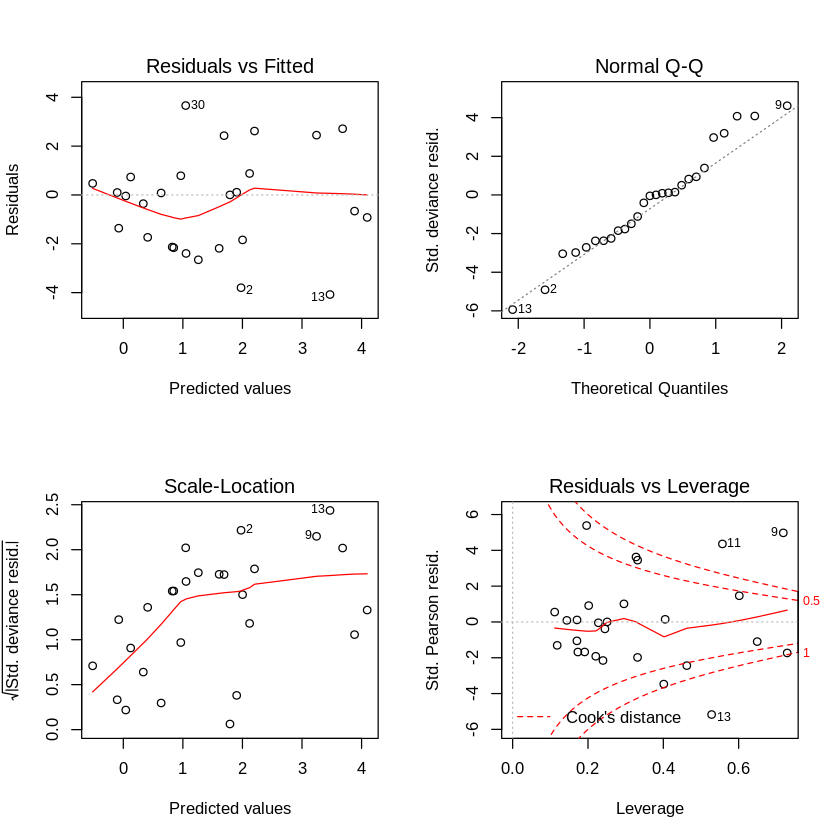

In [56]:
# Your Code Here
#library(repr)
#options(repr.plot.width = 1, repr.plot.height = 0.75) #, repr.plot.res = 100)
par(mfrow = c(2,2))
plot(glm_ships)
#dev.off()
#graphics.off()
par(mfrow=c(1,1))

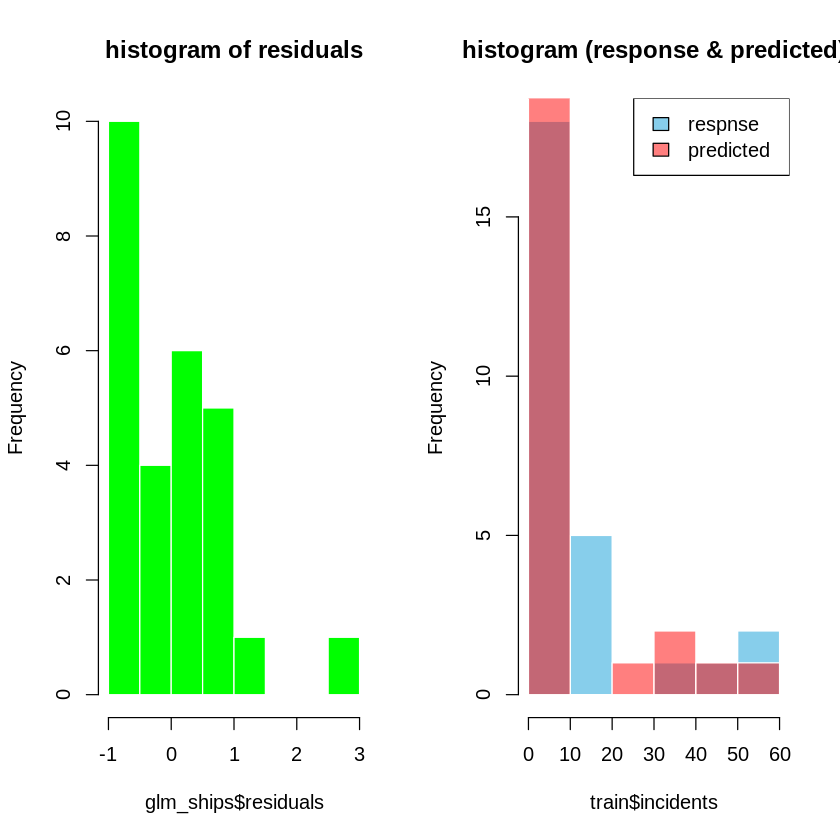

In [70]:
actual <- train$incidents
predicted <- predict(glm_ships, type='response')
par(mfrow = c(1,2))
hist(glm_ships$residuals, col='green', border=F, main='histogram of residuals')
hist(train$incidents, col='skyblue', border=F, main='histogram (response & predicted)')
hist(predicted, add=T, col=scales::alpha('red',.5), border=F)
legend('topright', legend=c('respnse', 'predicted'), fill=c('skyblue', scales::alpha('red',.5)))
par(mfrow = c(1,1))

The next code snippet plots the residual values against the linear predictor $\eta$. As can be seen, the linear regression model is very **bad fit** (although the **MSPE** is $133.236$, which is a little higher than the chosen possion regression model). 

The linear predictor clearly has violation of non-normality and homoskedasticity assumptions in residuals and has a presence of a strong pattern in he fitted-residual plot. 

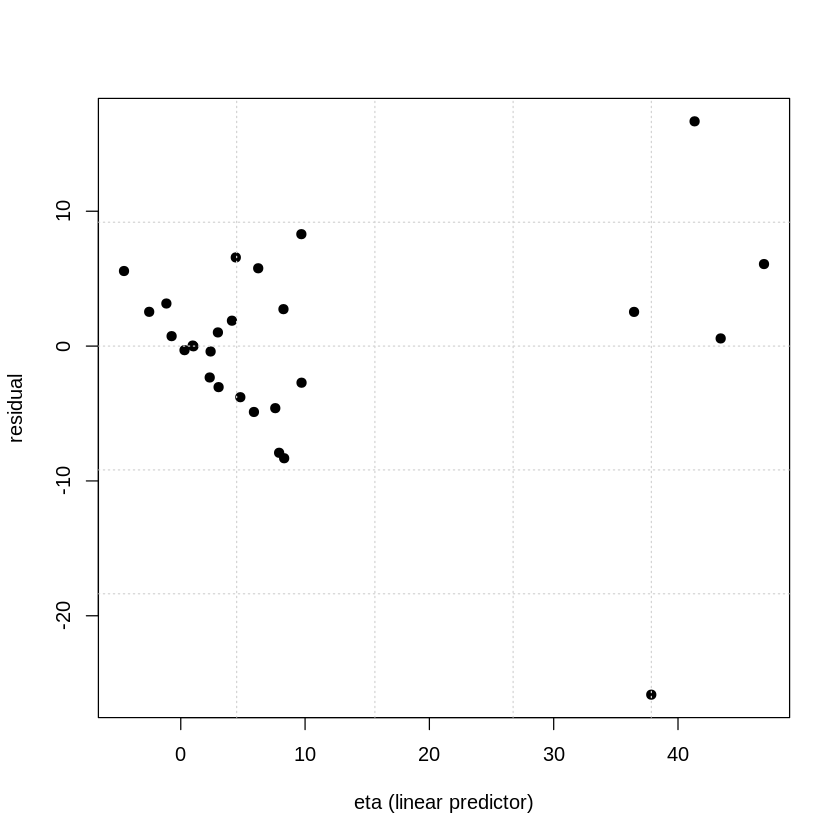

In [80]:
lm_ships = glm(incidents ~ type + period + year, data = train, family = gaussian) # linear model
eta = predict(lm_ships) # the linear predictor
plot(eta, lm_ships$residual, pch=19, xlab='eta (linear predictor)', ylab='residual')
grid(5,5)

In [89]:
MSPE = mean((test$incidents - predict(glm_ships, test))^2)
MSPE

[1] 133.236

### 2. (e) Overdispersion

For linear regression, the variance of the data is controlled through the standard deviation $\sigma$, which is independent of the other parameters like the mean $\mu$. However, some GLMs do not have this independence, which can lead to a problem called overdispersion. Overdispersion occurs when the observed data's variance is higher than expected, if the model is correct. 

For Poisson Regression, we expect that the mean of the data should equal the variance. If overdispersion is present, then the assumptions of the model are not being met and we can not trust its output (or our beloved p-values)!

Explore the two models fit in the beginning of this question for evidence of overdisperion. If you find evidence of overdispersion, you do not need to fix it (but it would be useful for you to know how to). Describe your process and conclusions.

### Answer:

Let's compute the mean and variance of the response variable `incidents` from the dataset, using the next code snippet, to check if we have overdispersion in this case. As can be seen, the variance is way to big than the mean, hence we have **overdispersion** here, violating the poission regression assumption.

The next code snippet computes the dispersions for the models and we observe that the dispersion $\Phi > 1$ for both the models ($6.07$ and $1.67$, respectively for the chosen and the full model), hence we can come to the conclusion that **both the poission regression models** have **overdispersion** that's why they were not adequate (with high values of residuals). 

In [93]:
# Your Code Here
mean(ships$incidents) # observed mean
var(ships$incidents)  # observed variance

deviance(glm_ships) / df.residual(glm_ships) # dispersion of the chosen model
deviance(glm_ships_full) / df.residual(glm_ships_full) # dispersion of the full model

[1] 10.47059

[1] 247.59

[1] 6.067349

[1] 1.636622